<a href="https://colab.research.google.com/github/HalyshAnton/ITStep-AI/blob/superwised_learning/Overfitting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Перенавчання та недонавчання моделі

## На прикладі дерева рішень для прогнозування ціни будинку

У цьому ноутбуці ми крок за кроком розберемо:
- як підготувати дані для навчання моделі;
- як працює дерево рішень для задачі регресії;
- як оцінювати якість моделі за допомогою метрик;
- що таке **недонавчання (underfitting)** та **перенавчання (overfitting)** і як їх виявляти.

Working example: прогнозування ціни будинку за його характеристиками.


## Імпорт бібліотек

Перед початком роботи підключимо потрібні бібліотеки:
- `pandas` — для роботи з таблицями даних;
- `numpy` — для математичних обчислень;
- `matplotlib` — для побудови графіків;
- `sklearn` — для побудови моделі та поділу даних.


In [2]:
import pandas as pd


## Знайомство з даними


In [3]:
df = pd.read_csv("https://raw.githubusercontent.com/HalyshAnton/ITStep-AI/refs/heads/superwised_learning/data/house_price.csv")
df.head()


,size,distance_to_center,age,price
0,1672,4.99,24,254595
1,976,3.85,38,154490
2,1998,3.33,7,315130
3,2156,7.05,15,408785
4,678,8.55,42,166815


## Поділ на X та y

Для навчання моделі дані потрібно розділити на дві частини:

- **X** — матриця ознак (features), тобто всі стовпці, на основі яких модель робитиме прогноз (площа будинку, кількість кімнат, рік побудови тощо);
- **y** — цільова змінна (target), те, що ми хочемо передбачити. У нашому випадку це **ціна будинку**.

Навіщо це потрібно? Модель навчається знаходити залежність між ознаками `X` та відповіддю `y`. Якщо не розділити дані таким чином, модель не зрозуміє, що саме є "питанням", а що — "правильною відповіддю".


In [5]:
X = df.drop(columns=["price"])
y = df["price"]


## Поділ на тренувальну та тестову вибірки

Якщо ми навчимо модель на всіх наявних даних і на цих же даних перевіримо її якість, то отримаємо занадто оптимістичну (і нечесну) оцінку. Модель могла просто **"запам'ятати"** дані, а не навчитися узагальнювати закономірність.

Тому дані ділять на дві частини:
- **тренувальна вибірка (train)** — на ній модель навчається;
- **тестова вибірка (test)** — на ній ми перевіряємо, наскільки добре модель працює на **нових, ще не бачених** даних.

Це імітує реальну ситуацію: модель у майбутньому буде отримувати нові дані, яких не було під час навчання.


In [6]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,     # 20% даних залишаємо для тестування
    random_state=42    # фіксуємо випадковість для відтворюваності результату
)

print("Тренувальна вибірка:", X_train.shape)
print("Тестова вибірка:", X_test.shape)


Тренувальна вибірка: (7712, 3)
Тестова вибірка: (1928, 3)


## Дерево рішень для регресії

**Дерево рішень (Decision Tree)** — це модель, яка навчається, послідовно розбиваючи дані на групи за значеннями ознак, щоб об'єкти в кожній групі були максимально схожими між собою за цільовою змінною.

### Як це працює для регресії

1. Алгоритм перебирає ознаки та порогові значення (наприклад, "площа > 100 м²") і обирає таке розбиття, яке найкраще зменшує розкид (дисперсію) значень `y` у отриманих групах.
2. Дані діляться на дві гілки: ті, що задовольняють умову, і ті, що ні.
3. Процес повторюється рекурсивно для кожної гілки, утворюючи дерево.
4. Коли дані потрапляють у кінцевий вузол (**лист**), прогнозом стає **середнє значення `y`** серед об'єктів, що потрапили в цей лист.

Візуально це виглядає як послідовність запитань типу "так/ні", які приводять нас до фінального прогнозу.

### Основні параметри дерева рішень

- **`max_depth`** — максимальна глибина дерева (кількість рівнів розбиттів). Чим більша глибина, тим складніші залежності може вивчити модель, але тим вищий ризик перенавчання.
- **`min_samples_split`** — мінімальна кількість об'єктів у вузлі, необхідна для того, щоб його можна було розбити далі.
- **`min_samples_leaf`** — мінімальна кількість об'єктів, яка має залишитися в кінцевому листі.
- **`max_features`** — максимальна кількість ознак, які розглядаються при пошуку найкращого розбиття.

Сьогодні ми детально зосередимося на параметрі **`max_depth`**, оскільки саме він найкраще ілюструє баланс між недонавчанням та перенавчанням.


## Тренування моделі

Створимо модель дерева рішень з обмеженою глибиною та навчимо її на тренувальних даних.


In [10]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor()
model.fit(X_train, y_train)


DecisionTreeRegressor()

In [11]:
y_pred = model.predict(X_test)
y_pred[:10]


array([144942., 315796., 282978., 243724., 150097., 207900., 323930.,
       330325., 379514., 293059.])

## Порівняння справжніх та спрогнозованих значень

Створимо таблицю, у якій поруч розмістимо реальні значення ціни (`y_test`) та значення, спрогнозовані моделлю (`y_pred`). Це найпростіший спосіб "на око" оцінити, наскільки добре працює модель.


In [12]:
comparison = pd.DataFrame({
    "Реальна ціна": y_test,
    "Прогнозована ціна": y_pred
})

comparison["Різниця"] = comparison["Реальна ціна"] - comparison["Прогнозована ціна"]
comparison.head(10)


,Реальна ціна,Прогнозована ціна,Різниця
6538,318556,144942.0,173614.0
668,325136,315796.0,9340.0
3685,279538,282978.0,-3440.0
1393,268985,243724.0,25261.0
6237,168745,150097.0,18648.0
6508,281897,207900.0,73997.0
8530,268350,323930.0,-55580.0
3101,223939,330325.0,-106386.0
6209,339079,379514.0,-40435.0
8661,289355,293059.0,-3704.0


## Обчислимо помилку моделі вручну

Щоб оцінити якість моделі одним числом, а не переглядати сотні рядків таблиці, обчислимо **середню похибку** прогнозу.

Ідея проста:
1. Для кожного об'єкта знаходимо різницю між реальним та спрогнозованим значенням.
2. Беремо цю різницю за модулем (щоб від'ємні та додатні відхилення не "скасовували" одне одного).
3. Усереднюємо ці значення по всій вибірці.

Спробуємо зробити це самостійно, використовуючи лише `pandas`.


In [13]:
comparison["Похибка (модуль різниці)"] = comparison["Різниця"].abs()

середня_похибка = comparison["Похибка (модуль різниці)"].mean()
print(f"Середня похибка моделі: {середня_похибка:.2f}")


Середня похибка моделі: 43592.34


Отримане число показує, наскільки в середньому (у грошових одиницях) прогноз моделі відхиляється від реальної ціни будинку. Далі ми побачимо, що ця метрика має власну назву та формулу — і що це лише одна з кількох метрик, якими користуються на практиці.


## Метрики якості регресії: теорія

Для оцінки якості регресійних моделей використовують кілька стандартних метрик. Нехай:
- $y_i$ — реальне значення для $i$-го об'єкта;
- $\hat{y}_i$ — прогнозоване значення моделі;
- $n$ — кількість об'єктів у вибірці.

### MAE (Mean Absolute Error) — середня абсолютна похибка

$$
MAE = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y}_i|
$$

Це саме та метрика, яку ми щойно обчислили вручну! Вона показує середнє абсолютне відхилення прогнозу від реального значення, у тих самих одиницях, що й цільова змінна.

### MSE (Mean Squared Error) — середньоквадратична похибка

$$
MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2
$$

Через піднесення до квадрата великі помилки "штрафуються" сильніше, ніж малі. Недолік — одиниці вимірювання стають квадратом одиниць `y`, що ускладнює інтерпретацію.

### RMSE (Root Mean Squared Error) — корінь із середньоквадратичної похибки

$$
RMSE = \sqrt{MSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}
$$

RMSE повертає одиниці вимірювання назад до одиниць `y`, зберігаючи при цьому підвищену чутливість до великих помилок.

### R² (коефіцієнт детермінації)

$$
R^2 = 1 - \frac{\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}{\sum_{i=1}^{n}(y_i - \bar{y})^2}
$$

де $\bar{y}$ — середнє значення реальних відповідей.

R² показує, **яку частку варіації цільової змінної пояснює модель**:
- $R^2 = 1$ — ідеальні прогнози;
- $R^2 = 0$ — модель прогнозує не краще, ніж просто середнє значення `y`;
- $R^2 < 0$ — модель працює гірше, ніж просте передбачення середнього.


## Обчислення метрик за допомогою scikit-learn

Обчислювати кожну метрику вручну незручно — `scikit-learn` вже має готові функції для цього.


In [15]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.2f}")
print(f"MSE:  {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2:   {r2:.4f}")


MAE:  43592.34
MSE:  3001735568.67
RMSE: 54788.10
R2:   0.4444


Порівняйте значення `MAE`, отримане тут, зі значенням, яке ви обчислили вручну на кроці 7 — вони мають збігатися.


## Порівняння метрик на тренувальній та тестовій вибірках

До цього моменту ми оцінювали модель лише на тестових даних. Але важливо також подивитися, **як модель показує себе на тих даних, на яких вона навчалась**.

Якщо метрики на тренувальній вибірці значно кращі, ніж на тестовій — це перша ознака того, що модель, можливо, "завчила" тренувальні дані, замість того щоб вивчити загальну закономірність.


In [16]:
y_train_pred = model.predict(X_train)

train_mae = mean_absolute_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

test_mae = mean_absolute_error(y_test, y_pred)
test_r2 = r2_score(y_test, y_pred)

metrics_comparison = pd.DataFrame({
    "Вибірка": ["Тренувальна", "Тестова"],
    "MAE": [train_mae, test_mae],
    "R2": [train_r2, test_r2]
})

metrics_comparison


,Вибірка,MAE,R2
0,Тренувальна,0.00000,1.000000
1,Тестова,43592.34388,0.444445


## Як якість моделі змінюється залежно від `max_depth`

Побудуємо графік залежності похибки моделі від глибини дерева (`max_depth` від 2 до 15) окремо для тренувальної та тестової вибірок. Це дозволить наочно побачити момент, коли модель починає перенавчатися.


In [18]:
max_depth_values = range(2, 16)

train_errors = []
test_errors = []

for depth in max_depth_values:
    tree = DecisionTreeRegressor(max_depth=depth, random_state=42)
    tree.fit(X_train, y_train)

    train_pred = tree.predict(X_train)
    test_pred = tree.predict(X_test)

    train_errors.append(mean_absolute_error(y_train, train_pred))
    test_errors.append(mean_absolute_error(y_test, test_pred))


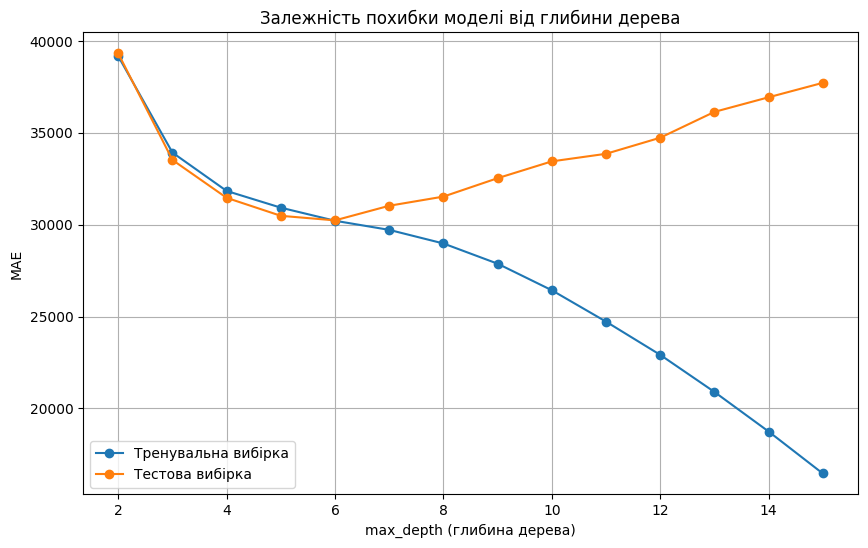

In [19]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10, 6))
plt.plot(max_depth_values, train_errors, marker="o", label="Тренувальна вибірка")
plt.plot(max_depth_values, test_errors, marker="o", label="Тестова вибірка")

plt.xlabel("max_depth (глибина дерева)")
plt.ylabel("MAE")
plt.title("Залежність похибки моделі від глибини дерева")
plt.legend()
plt.grid(True)
plt.show()


**Зверніть увагу на форму отриманого графіка:**
- Похибка на **тренувальній** вибірці майже завжди зменшується зі збільшенням `max_depth`.
- Похибка на **тестовій** вибірці спочатку теж зменшується, але з певного моменту починає зростати (або перестає покращуватись).

Саме ця точка "розходження" двох кривих — ключ до розуміння перенавчання.


## Недонавчання та перенавчання

### Недонавчання (Underfitting)

Модель **занадто проста**, щоб вловити закономірності в даних. Наприклад, дерево з `max_depth=1` майже не враховує жодних ознак і робить дуже грубі прогнози.

**Ознаки недонавчання:**
- висока похибка як на тренувальній, так і на тестовій вибірці;
- модель показує погані результати навіть на даних, які вона "бачила" під час навчання.

### Перенавчання (Overfitting)

Модель **занадто складна** і починає підлаштовуватися під конкретні тренувальні дані, включно з шумом та випадковими особливостями вибірки, замість того щоб вивчити загальну закономірність.

**Ознаки перенавчання:**
- дуже низька похибка на тренувальній вибірці;
- значно вища похибка на тестовій вибірці;
- велика "прірва" (gap) між метриками train і test.

### Баланс між ними

Мета — знайти "золоту середину": модель має бути достатньо складною, щоб вивчити реальні закономірності, але не настільки складною, щоб запам'ятовувати шум.

Це часто ілюструють у вигляді U-подібної кривої залежності тестової похибки від складності моделі:

[![Опис зображення](https://cdn.analyticsvidhya.com/wp-content/uploads/2020/02/Screenshot-2020-02-06-at-11.09.13.png)](https://cdn.analyticsvidhya.com/wp-content/uploads/2020/02/Screenshot-2020-02-06-at-11.09.13.png)

### Як боротися з перенавчанням

- обмежувати складність моделі (`max_depth`, `min_samples_leaf` тощо);
- використовувати більше тренувальних даних;
- застосовувати крос-валідацію для підбору гіперпараметрів;
- використовувати ансамблеві методи (наприклад, Random Forest), які менш схильні до перенавчання, ніж окреме дерево рішень.

**Питання для самоперевірки:**
1. Яке значення `max_depth` на вашому графіку виглядає оптимальним і чому?
2. Що станеться з похибкою на тренувальній вибірці, якщо `max_depth` необмежений? А з тестовою?
3. Чи можна перенавчитись, маючи дуже просту модель? Чому?
